# Library programs and events feed

Events organized at TPL's 

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
cwd = os.environ["REPO_ROOT"]
print(cwd)
os.chdir(cwd)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-branch-programs-and-events-feed"}
events_file = cwd+"/data/library-branch-programs-and-events-feed.csv"

download_data(params, events_file)

/home/ruchirich/Documents/repositories/toronto-open-data/tpl


# 0. Load data

In [ ]:
df = pd.read_csv(events_file)

# Convert date columns to `datetime64[ns]` datatype
df["startdate"] = pd.to_datetime(df["startdate"], format="%Y-%m-%d")
df["enddate"] = pd.to_datetime(df["enddate"], format="%Y-%m-%d")
df["lastupdated"] = pd.to_datetime(df["lastupdated"], format="ISO8601", utc=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4878 entries, 0 to 4877
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   _id              4878 non-null   int64              
 1   title            4878 non-null   object             
 2   startdate        4878 non-null   datetime64[ns]     
 3   enddate          23 non-null     datetime64[ns]     
 4   starttime        4855 non-null   object             
 5   endtime          4855 non-null   object             
 6   library          4878 non-null   object             
 7   location         2318 non-null   object             
 8   description      4878 non-null   object             
 9   pagelink         4878 non-null   object             
 10  id               4878 non-null   int64              
 11  rcid             4878 non-null   int64              
 12  eventtype1       4878 non-null   object             
 13  eventtype2       1

In [3]:
df.head()

,_id,title,startdate,enddate,starttime,endtime,library,location,description,pagelink,id,rcid,eventtype1,eventtype2,eventtype3,agegroup1,agegroup2,agegroup3,supportlink,supportlinktext,imagepath,imagetext,imageheight,imagewidth,otherinfo,lastupdated
0,1,Financial Empowerment Service,2025-07-22,2025-12-31,NaN,NaN,Cedarbrae,NaN,"Find help and learn how to improve your financial health and well-being. Our in-branch advisors and community partners from North York Community House can help those with low-income with tax filing, accessing government benefits, saving with limited cash flow, and planning for the future.<br /><br />Schedule a Financial Empowerment counselling session by calling 416-396-8850 or speaking to staff in-branch. You can also <a href=""https://calendly.com/tpl-financial-empowerment-4/cedarbrae?month=2025-07"">book an appointment at Cedarbrae online</a>.<br /><br />Appointments are available:<br />Tuesdays, 11:30 am - 4:00 pm<br />Wednesdays, 11:30 am - 4:00 pm<br />Thursdays, 10:30 am - 3:00 pm<br />Fridays, 10:30 am - 3:00 pm<br />Saturdays, 9:30 am - 3:00 pm<br /><br />Drop-in sessions are available:<br />Tuesdays, 6:00 pm - 7:00 pm<br />Wednesdays, 6:00 pm - 7:00 pm<br />Thursdays, 5:00 pm - 6:00 pm<br />Fridays, 5:00 pm - 6:00 pm<br />Saturdays, 3:30 - 4:30 pm",https://www.torontopubliclibrary.ca/detail.jsp?Entt=RDMEVT563582&R=EVT563582,563582,0,00-Personal Finance,NaN,NaN,Adult,Older Adult,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-23 13:26:58+00:00
1,2,Branch Art Exhibit: Works by Kayla Free,2025-09-03,2025-09-29,NaN,NaN,North York Central Library,NaN,"Throughout September, works by artist Kayla Free are on display at North York Central Library branch.<br /><br />Kayla Free, a Toronto-born illustrator, discovered her love of drawing at a young age and has since pursued her creative passion. She earned a Bachelor of Design with a major in Illustration in 2015 at OCADU. She starts her illustrations from a doodle or improv, using colors and textures from magazines, posters, and scraps, which are then handcrafted or digitally pieced. Her work was included in 'Life on the Line,' a public art mental health awareness campaign on the Toronto TTC Subway in 2018.<br /><br />""Kayla's work explores the inner landscapes of the human spirit by using visual metaphors to illustrate tales of biblical passages. In her art, she presents her unique musings on Biblical texts in a whimsical, child-like style with the goal of engaging her audience to delve into the spiritual components of life. She also has a special place in her heart for her late father, who was both her spiritual and creative mentor. He helped her understand how biblical passages were artistically evoked in her earlier artwork. Her art is both a testimony to her faith and a tribute to her father.""<br /><br />This exhibit is part of TPL's <a href=""https://www.torontopubliclibrary.ca/programs-and-classes/exhibits/art-exhibit-space.jsp"">Art Exhibit Space</a> program. Toronto Public Library provides space for local artists to exhibit their work at locations across the city. These exhibits aim to reflect the diverse cultural interests of the city and its neighbourhoods. <br /><br />The exhibit can be viewed during North York Central Library open hours. Please check the <a href=""https://www.torontopubliclibrary.ca/northyorkcentral/"">North York Central Library</a> page before your visit. <br /><br />Free. All are welcome.<br /><br />Image credit: Artist: Kayla Free; The Pit.<br />",https://www.torontopubliclibrary.ca/detail.jsp?Entt=RDMEVT567043&R=EVT567043,567043,0,01-Branch Art Exhibits,00-Art Exhibits,00-Culture Arts & Entertainment,Adult,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""smallImageURL"":""https://tpl.razuna.com/assets/3434/3F8EF93C0A684DD5A82C2A9275C2FF62/img/24C10AD257764080B079E608DB1B4A34/Branch_Art_Exhibit_-_Sep_2025_-_Kayla_Free_-_E_vents_600x740_24C10AD257764080B079E608DB1B4A34.jpg"",""mediumImageURL"":""https://tpl.razuna.com/assets/3434/3F8EF93C0A68

# 1. Events Count across different feature dimensions

## 1.1. Count of Events across Library Branches

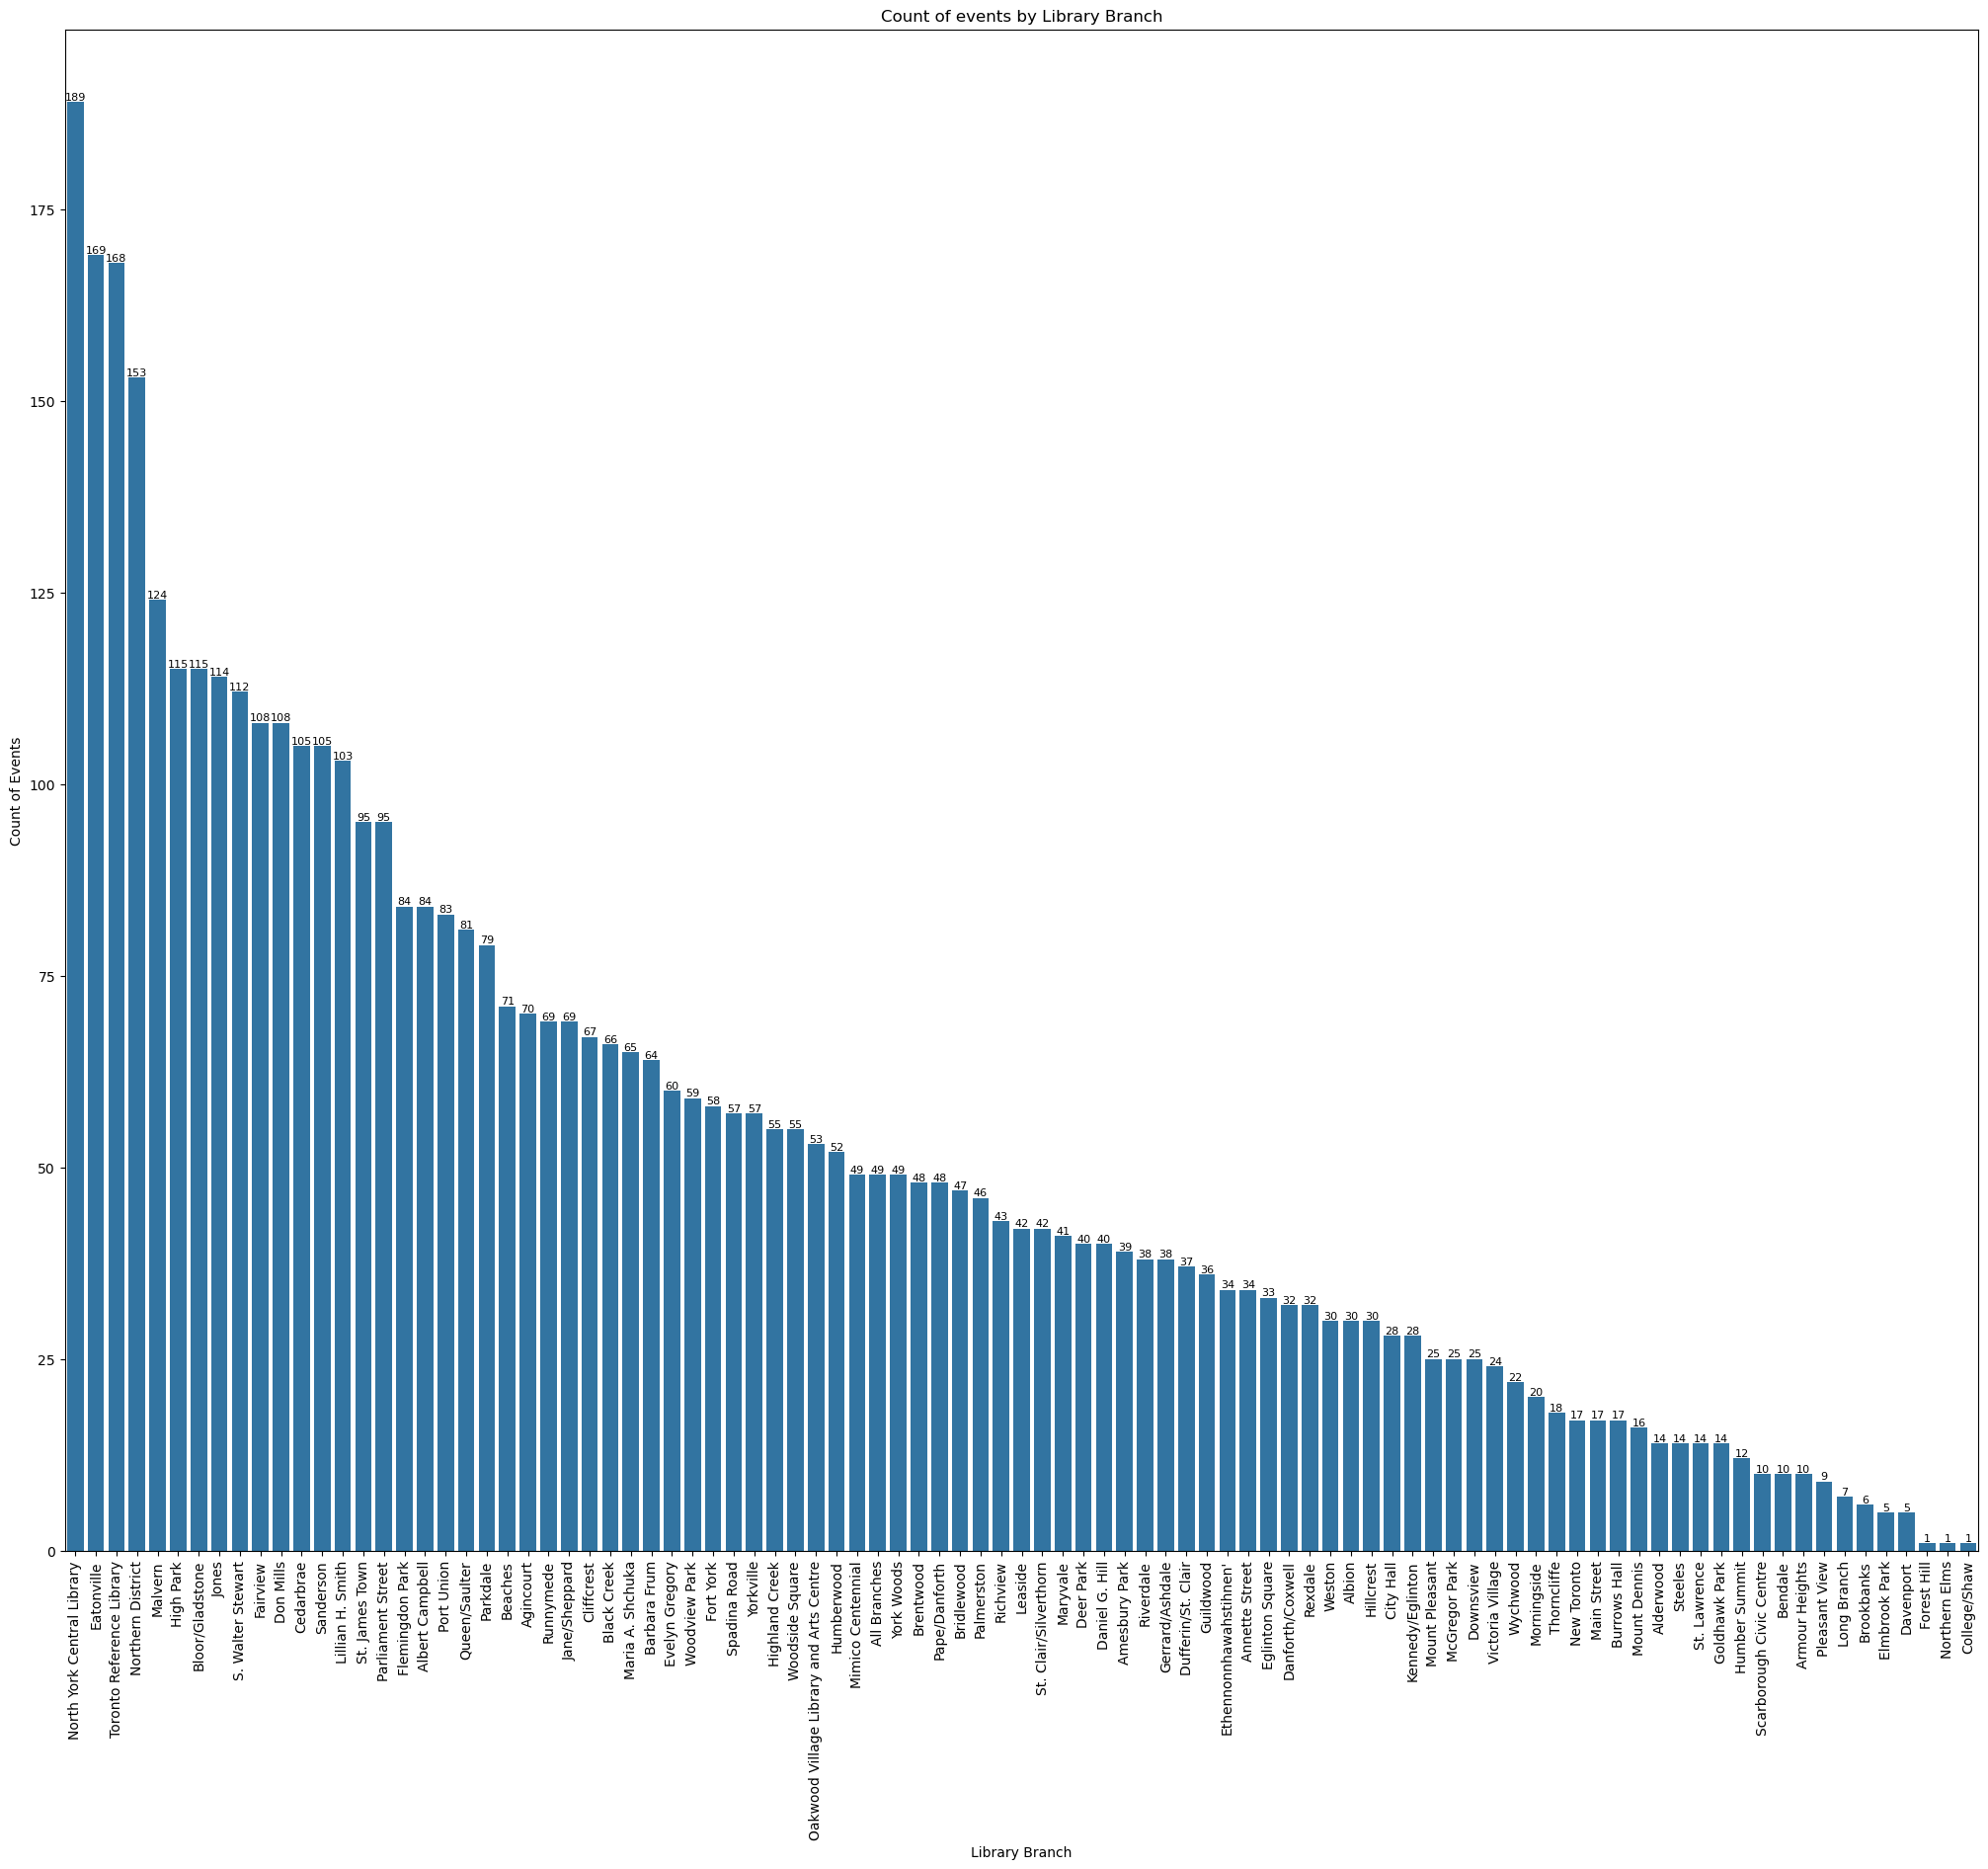

In [ ]:
event_counts_by_library = df.library.value_counts()

fig, ax = plt.subplots(figsize=(25,20))
sns.barplot(data=event_counts_by_library)

ax.set(
    title="Count of Events across Library Branches",
    xlabel="Library Branch",
    ylabel="Count of Events"
)

ax.bar_label(container=ax.containers[0], fontsize=8)

plt.xticks(rotation=90)

# plt.tight_layout()
plt.show()
fig.savefig(fname="output/events/count_of_events_by_library_branch.png")

## 1.2. Count of Events across Start Dates

In [ ]:
event_counts_by_start_date = df.startdate.value_counts().sort_index(ascending=False)
print()
event_counts_by_start_date.describe()

count    129.000000
mean      37.813953
std       27.135588
min        1.000000
25%       19.000000
50%       35.000000
75%       52.000000
max      110.000000
Name: count, dtype: float64

Events from 2024/12/13 to 2025/12/24


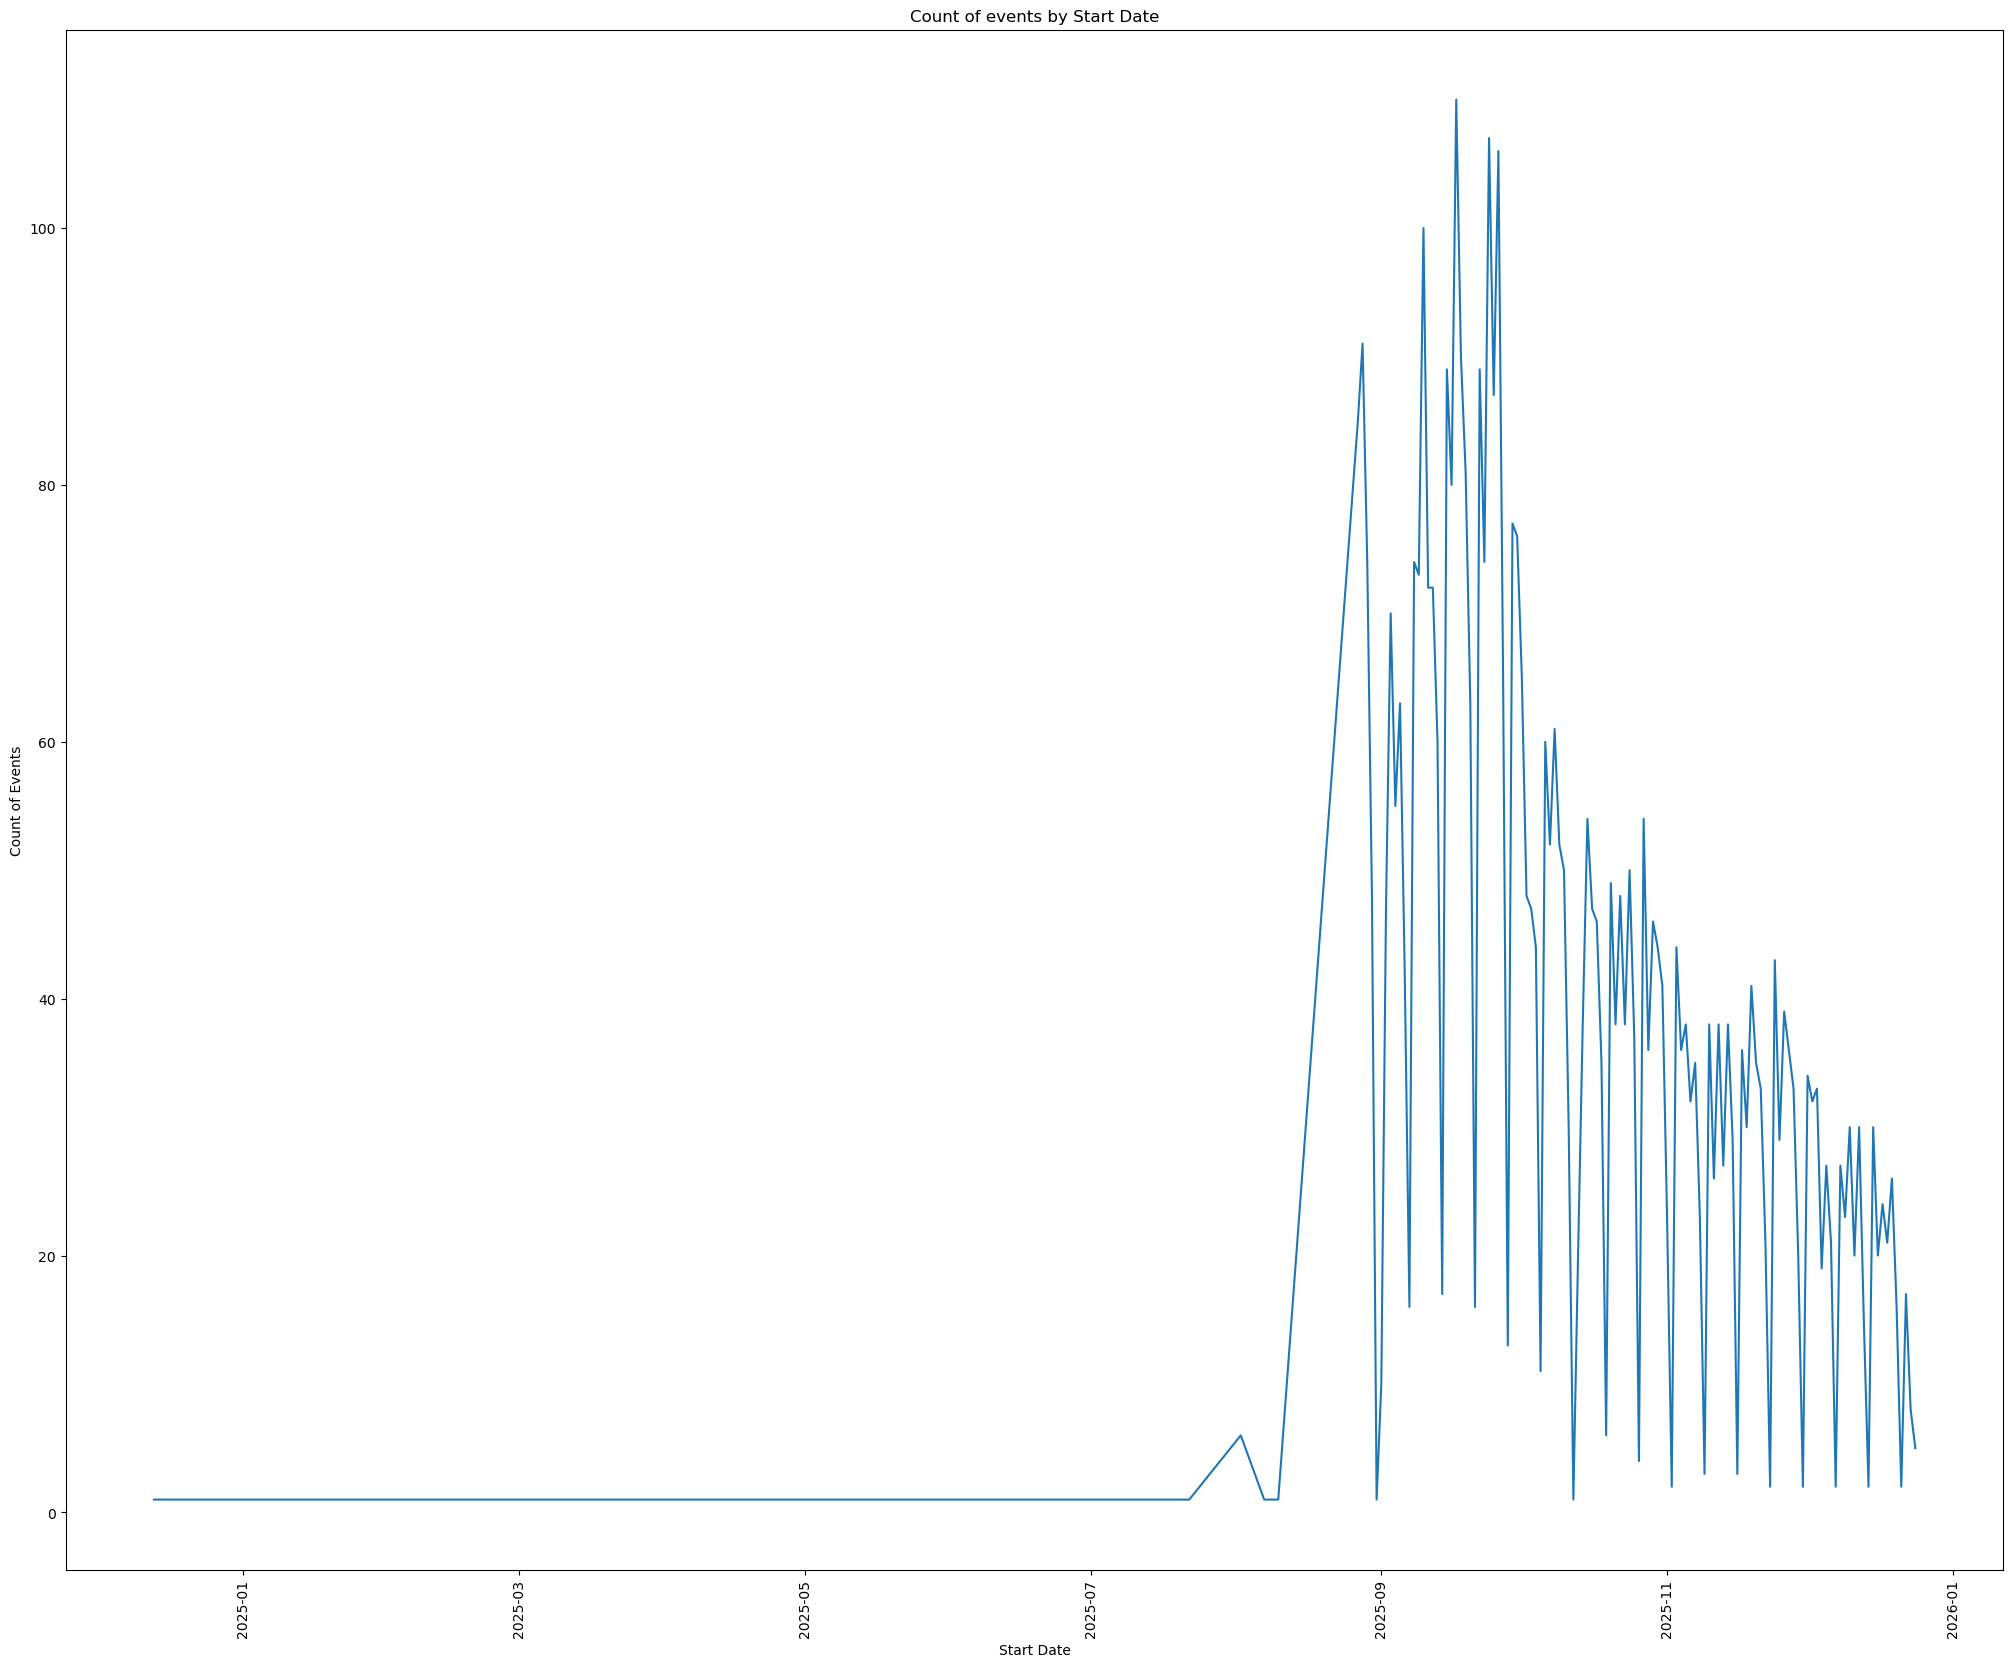

In [114]:
event_timeseries_df = pd.DataFrame(data={"Year": event_counts_by_start_date.index.year,
                                         "month": event_counts_by_start_date.index.month,
                                         "day": event_counts_by_start_date.index.day,
                                         "counts":event_counts_by_start_date.values})

min = event_counts_by_start_date.index.strftime("%Y/%m/%d").min()
max = event_counts_by_start_date.index.strftime("%Y/%m/%d").max()

print(f"Events from {min} to {max}")

fig, ax = plt.subplots(figsize=(25,20))
sns.lineplot(data=event_counts_by_start_date)

ax.set(
    title="Count of events by Start Date",
    xlabel="Start Date",
    ylabel="Count of Events"
)

plt.xticks(rotation=90)
plt.show()
fig.savefig(fname="output/events/count_of_events_by_library_branch.png")

In [112]:
df_biggest_events_day = df[df["startdate"] == "2025-09-17"]

In [122]:
df_biggest_events_day.library.value_counts()

library
Toronto Reference Library     4
Agincourt                     4
St. James Town                4
Black Creek                   3
North York Central Library    3
                             ..
Kennedy/Eglinton              1
Parliament Street             1
Runnymede                     1
Scarborough Civic Centre      1
Jane/Sheppard                 1
Name: count, Length: 69, dtype: int64

In [117]:
df.library.value_counts()

library
North York Central Library    189
Eatonville                    169
Toronto Reference Library     168
Northern District             153
Malvern                       124
                             ... 
Elmbrook Park                   5
Davenport                       5
Forest Hill                     1
Northern Elms                   1
College/Shaw                    1
Name: count, Length: 93, dtype: int64

In [56]:
monthly_events_ts = event_timeseries_df.groupby(by=["Year", "month"]).agg(func="sum").drop(columns="day").reset_index()

monthly_events_ts["date"] = pd.to_datetime(monthly_events_ts[["Year", "month"]].assign(DAY=1))

In [59]:
monthly_events_ts

,Year,month,counts,date
0,2024,12,1,2024-12-01
1,2025,1,2,2025-01-01
2,2025,2,1,2025-02-01
3,2025,6,1,2025-06-01
4,2025,7,1,2025-07-01
5,2025,8,307,2025-08-01
6,2025,9,1994,2025-09-01
7,2025,10,1252,2025-10-01
8,2025,11,835,2025-11-01
9,2025,12,484,2025-12-01


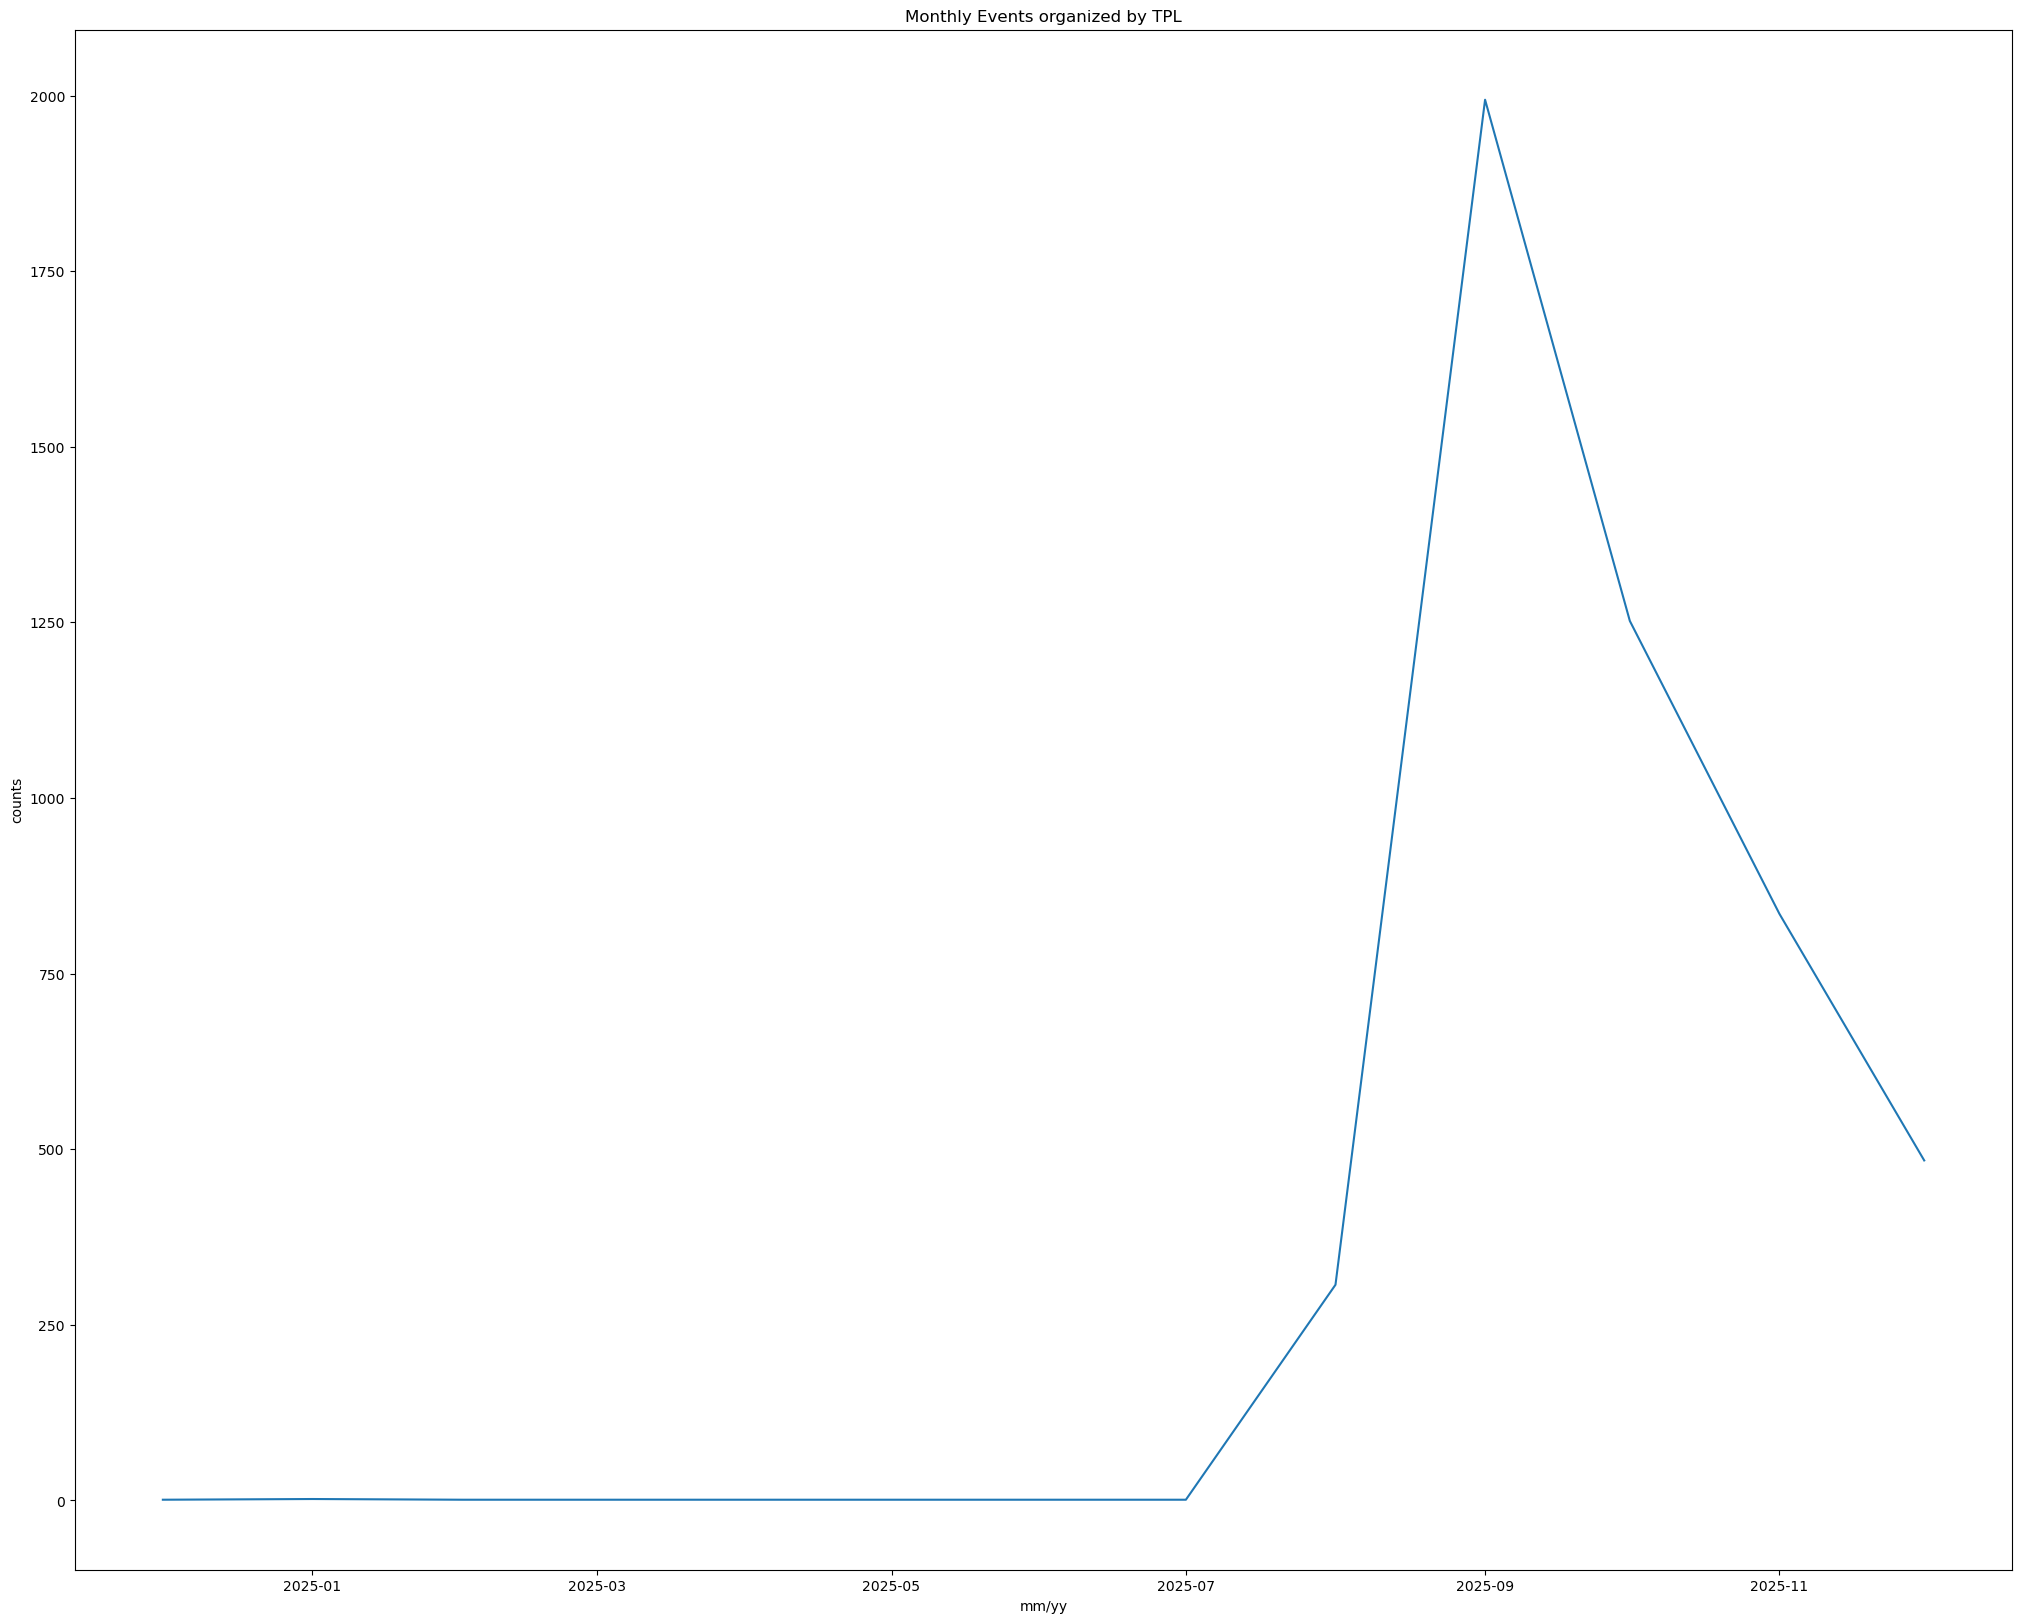

In [58]:
fig, ax = plt.subplots(figsize=(25, 20))
sns.lineplot(data=monthly_events_ts, x="date", y="counts")

ax.set(
    title="Monthly Events organized by TPL",
    xlabel="mm/yy",
    ylabel="counts"
)

fig.savefig("output/events/monthly_events_count.png")

In [5]:
df_NY = df[df.library == "North York Central Library"].sort_values(by="lastupdated", ascending=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4878 entries, 0 to 4877
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   _id              4878 non-null   int64              
 1   title            4878 non-null   object             
 2   startdate        4878 non-null   datetime64[ns]     
 3   enddate          23 non-null     datetime64[ns]     
 4   starttime        4855 non-null   object             
 5   endtime          4855 non-null   object             
 6   library          4878 non-null   object             
 7   location         2318 non-null   object             
 8   description      4878 non-null   object             
 9   pagelink         4878 non-null   object             
 10  id               4878 non-null   int64              
 11  rcid             4878 non-null   int64              
 12  eventtype1       4878 non-null   object             
 13  eventtype2       1

In [6]:
df_NY.head()

_id                                                     title  \
2469  2470                 2025 Digital Expo: Bridging the AI Divide   
1059  1060                   No Filter Required: Tips for great skin   
2468  2469  Digital Expo 2025: Children's Programming and Exhibitors   
1917  1918               Legal Workshop: Housing and Tenants Rights   
1        2                   Branch Art Exhibit: Works by Kayla Free   

      startdate    enddate starttime  endtime                     library  \
2469 2025-10-04        NaT   9:30 AM  4:30 PM  North York Central Library   
1059 2025-09-13        NaT   2:00 PM  3:00 PM  North York Central Library   
2468 2025-10-04        NaT   9:30 AM  4:30 PM  North York Central Library   
1917 2025-09-25        NaT   3:00 PM  4:00 PM  North York Central Library   
1    2025-09-03 2025-09-29       NaN      NaN  North York Central Library   

                   location  \
2469  Concourse Event Space   
1059                 Room 1   
2468                    NaN   
1917               Room 2/3   
1                       NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [7]:
df_NY[df_NY["title"].str.contains("Applefun")][["title", "description"]]

,title,description
307,Applefun Puppet Show: Forest Trek,"Boldly go where no puppets have gone before with Applefun Puppetry! Join us for 45 minutes of interactive fun, followed by a paper puppet craft that you can take home. For kids of all ages. <br /><br /><b>Drop-in, until room capacity is reached. No registration required.</b><br /><br />If you or your child lives with a disability, and requires an accessibility accommodation to participate in this program, please contact Accessibility Services by email accessibleservices@tpl.ca, or voicemail, 416-393-7099, to make a request. Please contact us at least three weeks in advance.<br /><br />"


In [8]:
df_NY.location.unique()

array(['Concourse Event Space', 'Room 1', nan, 'Room 2/3', 'Room 101',
       'Elearning Lab', 'Auditorium', 'Fabrication Studio'], dtype=object)

In [9]:
event_groups = df_NY.groupby(['eventtype1', 'eventtype2', 'eventtype3'])

In [10]:
event_groups.head()

_id                                                        title  \
2469  2470                    2025 Digital Expo: Bridging the AI Divide   
1        2                      Branch Art Exhibit: Works by Kayla Free   
755    756                                  Percussion Basics with LMMS   
1541  1542                                Introduction to Serger Sewing   
1780  1781                           Introduction to Machine Embroidery   
1640  1641                                        Introduction to Krita   
1526  1527                                Introduction to Serger Sewing   
1200  1201                           Introduction to Machine Embroidery   
565    566                           Introduction to Machine Embroidery   
968    969                           Introduction to Machine Embroidery   
683    684                                Introduction to Serger Sewing   
1576  1577  Learning Circle: Parenting a Child with Extra Support Needs   
11      12           Branch Art Exhibit: Digital Art by Mr. Robert Hall   
65      66                           Introduction to Machine Embroidery   
2368  2369                                             Talk About Books   
442    443                                             Talk About Books   
3700  3701                                             Talk About Books   
4490  4491                                             Talk About Books   

      startdate    enddate starttime   endtime                     library  \
2469 2025-10-04        NaT   9:30 AM   4:30 PM  North York Central Library   
1    2025-09-03 2025-09-29       NaN       NaN  North York Central Library   
755  2025-09-09        NaT   6:30 PM   8:00 PM  North York Central Library   
1541 2025-09-20        NaT  10:00 AM  12:00 PM  North York Central Library   
1780 2025-09-24        NaT  10:00 AM  12:00 PM  North York Central Library   
1640 2025-09-22        NaT   2:00 PM   3:30 PM  North York Central Library   
1526 2025-09-19        NaT   6:00 PM   8:00 PM  North York Central Library   
1200 2025-09-16        NaT   2:00 PM   4:00 PM  North York Central Library   
565  2025-09-06        NaT  10:00 AM  12:00 PM  North York Central Library   
968  2025-09-12        NaT   2:00 PM   4:00 PM  North York Central Library   
683  2025-09-08        NaT   6:00 PM   8:00 PM  North York Central Library   
1576 2025-09-20        NaT   2:00 PM   3:30 PM  North York Central Library   
11   2025-08-07 2025-08-30       NaN       NaN  North York Central Library   
65   2025-08-27        NaT   2:00 PM   4:00 PM  North York Central Library   
2368 2025-10-01        NaT   7:00 PM   8:00 PM  North York Central Library   
442  2025-09-03        NaT   7:00 PM   8:00 PM  North York Central Library   
3700 2025-11-05        NaT   7:00 PM   8:00 PM  North York Central Library   
4490 2025-12-03        NaT   7:00 PM   8:00 PM  North York Central Library   

                   location  \
2469  Concourse Event Space   
1                       NaN   
755           Elearning Lab   
1541     Fabrication Studio   
1780     Fabrication Studio   
1640          Elearning Lab   
1526     Fabrication Studio   
1200     Fabrication Studio   
565      Fabrication Studio   
968      Fabrication Studio   
683      Fabrication Studio   
1576               Room 2/3   
11                      NaN   
65       Fabrication Studio   
2368               Room 2/3   
442                Room 2/3   
3700               Room 2/3   
4490               Room 2/3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [11]:
event_groups.indices

{('00-Book Clubs & Writers Groups',
  '00-Author Talks & Lectures',
  '00-Hobbies Crafts & Games'): array([180, 181, 182, 183]),
 ('00-Computer & Library Training',
  '01-Digital Innovation',
  '01-Maker Programs'): array([41, 47]),
 ('00-Conversation Circles',
  '00-Health & Wellness',
  '01-Learning Circle'): array([129]),
 ('00-Hobbies Crafts & Games',
  '01-Fabrication Studio',
  '01-Maker Programs'): array([42, 48, 53]),
 ('00-Science & Technology',
  '01-AI and Algorithmic Literacy',
  '01-Digital Inclusion Week'): array([0]),
 ('01-Branch Art Exhibits',
  '00-Art Exhibits',
  '00-Culture Arts & Entertainment'): array([  4, 130]),
 ('01-Fabrication Studio',
  '00-Hobbies Crafts & Games',
  '01-Maker Programs'): array([ 46,  50,  51,  52, 161])}

In [12]:
group_1 = event_groups.get_group(('00-Science & Technology', '01-AI and Algorithmic Literacy', '01-Digital Inclusion Week'))

In [13]:
group_1.head()

_id                                      title  startdate enddate  \
2469  2470  2025 Digital Expo: Bridging the AI Divide 2025-10-04     NaT   

     starttime  endtime                     library               location  \
2469   9:30 AM  4:30 PM  North York Central Library  Concourse Event Space   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [14]:
event_groups.head().sort_values(by="startdate", ascending=False)

_id                                                        title  \
4490  4491                                             Talk About Books   
3700  3701                                             Talk About Books   
2469  2470                    2025 Digital Expo: Bridging the AI Divide   
2368  2369                                             Talk About Books   
1780  1781                           Introduction to Machine Embroidery   
1640  1641                                        Introduction to Krita   
1541  1542                                Introduction to Serger Sewing   
1576  1577  Learning Circle: Parenting a Child with Extra Support Needs   
1526  1527                                Introduction to Serger Sewing   
1200  1201                           Introduction to Machine Embroidery   
968    969                           Introduction to Machine Embroidery   
755    756                                  Percussion Basics with LMMS   
683    684                                Introduction to Serger Sewing   
565    566                           Introduction to Machine Embroidery   
1        2                      Branch Art Exhibit: Works by Kayla Free   
442    443                                             Talk About Books   
65      66                           Introduction to Machine Embroidery   
11      12           Branch Art Exhibit: Digital Art by Mr. Robert Hall   

      startdate    enddate starttime   endtime                     library  \
4490 2025-12-03        NaT   7:00 PM   8:00 PM  North York Central Library   
3700 2025-11-05        NaT   7:00 PM   8:00 PM  North York Central Library   
2469 2025-10-04        NaT   9:30 AM   4:30 PM  North York Central Library   
2368 2025-10-01        NaT   7:00 PM   8:00 PM  North York Central Library   
1780 2025-09-24        NaT  10:00 AM  12:00 PM  North York Central Library   
1640 2025-09-22        NaT   2:00 PM   3:30 PM  North York Central Library   
1541 2025-09-20        NaT  10:00 AM  12:00 PM  North York Central Library   
1576 2025-09-20        NaT   2:00 PM   3:30 PM  North York Central Library   
1526 2025-09-19        NaT   6:00 PM   8:00 PM  North York Central Library   
1200 2025-09-16        NaT   2:00 PM   4:00 PM  North York Central Library   
968  2025-09-12        NaT   2:00 PM   4:00 PM  North York Central Library   
755  2025-09-09        NaT   6:30 PM   8:00 PM  North York Central Library   
683  2025-09-08        NaT   6:00 PM   8:00 PM  North York Central Library   
565  2025-09-06        NaT  10:00 AM  12:00 PM  North York Central Library   
1    2025-09-03 2025-09-29       NaN       NaN  North York Central Library   
442  2025-09-03        NaT   7:00 PM   8:00 PM  North York Central Library   
65   2025-08-27        NaT   2:00 PM   4:00 PM  North York Central Library   
11   2025-08-07 2025-08-30       NaN       NaN  North York Central Library   

                   location  \
4490               Room 2/3   
3700               Room 2/3   
2469  Concourse Event Space   
2368               Room 2/3   
1780     Fabrication Studio   
1640          Elearning Lab   
1541     Fabrication Studio   
1576               Room 2/3   
1526     Fabrication Studio   
1200     Fabrication Studio   
968      Fabrication Studio   
755           Elearning Lab   
683      Fabrication Studio   
565      Fabrication Studio   
1                       NaN   
442                Room 2/3   
65       Fabrication Studio   
11                      NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            